In [20]:
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict
from dotenv import load_dotenv

In [21]:
load_dotenv()

True

In [22]:
model = ChatMistralAI()

In [23]:
# create a state

class LLMState(TypedDict):

    question: str
    answer: str

In [24]:
def llm_qa(state: LLMState) -> LLMState:

    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer

    return state

In [25]:
# create our graph

graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# compile
workflow = graph.compile()

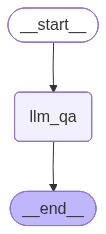

In [26]:
workflow

In [27]:
# execute

intial_state = {'question': 'How far is moon from the earth?'}

final_state = workflow.invoke(intial_state)

print(final_state['answer'])

HTTPStatusError: Error response 401 while fetching https://api.mistral.ai/v1/chat/completions: {"detail":"Unauthorized"}

In [ ]:
model.invoke('How far is moon from the earth?').content

HTTPStatusError: Error response 401 while fetching https://api.mistral.ai/v1/chat/completions: {"detail":"Unauthorized"}